# 11. Real-World Problem Solving Using Supervised and Unsupervised Learning

## 📚 Learning Objectives

By completing this notebook, you will:
- Solve real-world problems
- Combine supervised and unsupervised learning
- Apply ML techniques
- Evaluate solutions
- Present results

## 🔗 Prerequisites

- ✅ Understanding of supervised learning
- ✅ Understanding of unsupervised learning
- ✅ Problem-solving skills

---

This notebook covers practical activities from **Course 05, Unit 4**:
- Real-world problem solving using a mix of supervised and unsupervised learning algorithms

---

## Introduction

**Real-world problem solving** often requires combining supervised and unsupervised learning techniques to address complex data science challenges effectively.

## The Story

**BEFORE**: You know individual ML techniques but haven't applied them to solve complete real-world problems.

**AFTER**: You'll solve a complete real-world problem: from data to model to evaluation - end-to-end ML project!

**Why this matters**: Real-World Problem Solving Using Supervised and Unsupervised Learning is essential for building complete, professional data science solutions!

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Real-world dataset
- sklearn, pandas

**Outputs:** What you'll see when you run the cells

- Supervised + unsupervised mix
- Models
- Insights

---

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

print("✅ Libraries imported!")
print("\nReal-World Problem Solving: End-to-End Mini Project")
print("=" * 60)
print("""
Scenario: a subscription company wants to
  1. SEGMENT its customers (unsupervised - no labels needed)
  2. PREDICT which customers will churn (supervised - labeled history)

Plan: data -> explore -> K-Means segments -> churn model -> insights
""")

✅ Libraries imported!

Real-World Problem Solving: End-to-End Mini Project

Scenario: a subscription company wants to
  1. SEGMENT its customers (unsupervised - no labels needed)
  2. PREDICT which customers will churn (supervised - labeled history)

Plan: data -> explore -> K-Means segments -> churn model -> insights



## Step 1: The Data

We simulate a realistic customer table (in a real project this would be a
database export). `churn` is our supervised label.

In [2]:
print("Step 1: Load and explore the data")
print("-" * 60)

rng = np.random.default_rng(42)
n = 600
age = rng.normal(40, 12, n).clip(18, 75)
income = rng.normal(60, 20, n).clip(15, 150)            # thousands
monthly_spend = (income * 0.8 + rng.normal(0, 10, n)).clip(5, 200)
tenure_months = rng.integers(1, 72, n)
support_calls = rng.poisson(2, n)

# Churn is more likely with many support calls, short tenure, low spend
churn_logit = 0.55 * support_calls - 0.045 * tenure_months - 0.012 * monthly_spend + 0.3
churn = (rng.random(n) < 1 / (1 + np.exp(-churn_logit))).astype(int)

customers = pd.DataFrame({
    'age': age.round(0), 'income_k': income.round(1),
    'monthly_spend': monthly_spend.round(1),
    'tenure_months': tenure_months, 'support_calls': support_calls,
    'churn': churn,
})
print(customers.head().to_string())
print(f"\n{n} customers, overall churn rate: {churn.mean():.1%}")
print("\nSummary statistics:")
print(customers.describe().round(1).to_string())

Step 1: Load and explore the data
------------------------------------------------------------
    age  income_k  monthly_spend  tenure_months  support_calls  churn
0  44.0      70.3           43.0             29              1      0
1  28.0      48.4           33.9             45              2      1
2  49.0      85.5           72.6             14              1      1
3  51.0      47.4           36.9             24              4      0
4  18.0      47.3           31.3             29              1      1

600 customers, overall churn rate: 36.8%

Summary statistics:
         age  income_k  monthly_spend  tenure_months  support_calls  churn
count  600.0     600.0          600.0          600.0          600.0  600.0
mean    39.8      59.8           47.1           34.9            2.0    0.4
std     11.4      19.6           18.7           20.5            1.4    0.5
min     18.0      15.0            5.0            1.0            0.0    0.0
25%     32.0      47.2           34.8          

## Step 2: Unsupervised — Customer Segments with K-Means

No labels here: we cluster on behavior (income, spend, tenure) to find
natural customer groups the marketing team can target.

Step 2: K-Means customer segmentation
------------------------------------------------------------
Segment profiles (means):
         income_k  monthly_spend  tenure_months  churn  size
segment                                                     
0           70.19          57.99          18.15   0.44   216
1           39.69          27.86          35.01   0.43   208
2           70.67          56.49          55.26   0.21   176


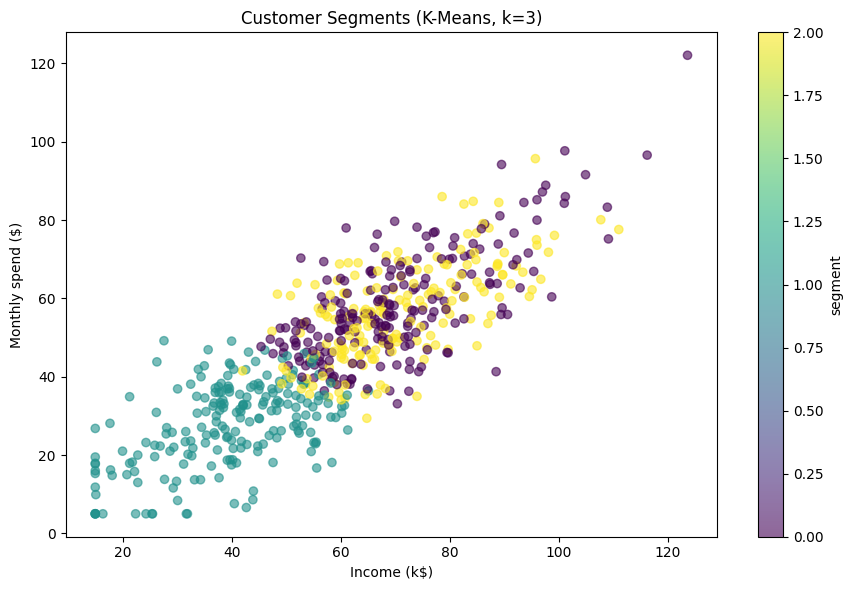

✓ Segments plotted - each color is a discovered customer group


In [3]:
print("Step 2: K-Means customer segmentation")
print("-" * 60)

seg_features = ['income_k', 'monthly_spend', 'tenure_months']
scaler_seg = StandardScaler()
X_seg = scaler_seg.fit_transform(customers[seg_features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customers['segment'] = kmeans.fit_predict(X_seg)

profile = customers.groupby('segment')[seg_features + ['churn']].mean().round(2)
profile['size'] = customers['segment'].value_counts().sort_index()
print("Segment profiles (means):")
print(profile.to_string())

plt.figure(figsize=(9, 6))
sc = plt.scatter(customers['income_k'], customers['monthly_spend'],
                 c=customers['segment'], cmap='viridis', alpha=0.6)
plt.colorbar(sc, label='segment')
plt.title('Customer Segments (K-Means, k=3)')
plt.xlabel('Income (k$)')
plt.ylabel('Monthly spend ($)')
plt.tight_layout()
plt.show()
print("✓ Segments plotted - each color is a discovered customer group")

## Step 3: Supervised — Predict Churn

Now we use the labeled history (`churn`) to train a classifier.

In [4]:
print("Step 3: Churn prediction with logistic regression")
print("-" * 60)

features = ['age', 'income_k', 'monthly_spend', 'tenure_months', 'support_calls']
X = customers[features]
y = customers['churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

churn_model = LogisticRegression()
churn_model.fit(X_train_s, y_train)
y_pred = churn_model.predict(X_test_s)
acc = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {acc:.2%}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

print("Model coefficients (standardized features -> comparable):")
coef_order = sorted(zip(features, churn_model.coef_[0]),
                    key=lambda t: abs(t[1]), reverse=True)
for name, c in coef_order:
    direction = "raises" if c > 0 else "lowers"
    print(f"  {name:15s} {c:+.3f}  ({direction} churn risk)")

Step 3: Churn prediction with logistic regression
------------------------------------------------------------
Test accuracy: 67.33%

Classification report:
              precision    recall  f1-score   support

           0      0.705     0.832     0.763        95
           1      0.579     0.400     0.473        55

    accuracy                          0.673       150
   macro avg      0.642     0.616     0.618       150
weighted avg      0.659     0.673     0.657       150

Model coefficients (standardized features -> comparable):
  tenure_months   -0.916  (lowers churn risk)
  support_calls   +0.855  (raises churn risk)
  monthly_spend   -0.252  (lowers churn risk)
  age             -0.168  (lowers churn risk)
  income_k        +0.082  (raises churn risk)


In [5]:
print("=" * 60)
print("Step 4: Insights & Summary")
print("=" * 60)

seg_churn = customers.groupby('segment')['churn'].mean()
riskiest = seg_churn.idxmax()
top_driver = coef_order[0][0]
print(f"""
End-to-end project - what the DATA told us (all computed above):
  - Churn rate by segment: {', '.join(f'segment {s}: {r:.1%}' for s, r in seg_churn.items())}
  - Riskiest segment: {riskiest} ({seg_churn[riskiest]:.1%} churn)
  - Strongest churn driver in the model: {top_driver}
  - Churn model test accuracy: {acc:.2%}

The full workflow we just executed:
  1. Data collection & exploration (pandas)
  2. Unsupervised segmentation (K-Means) - no labels needed
  3. Supervised prediction (logistic regression) - labeled history
  4. Insights that combine both: which SEGMENTS carry churn risk

Next: Example 12 asks what happens to this workflow when data
gets much bigger - CPU vs GPU for ML.
""")
print("✅ End-to-end real-world problem solving - complete!")

Step 4: Insights & Summary

End-to-end project - what the DATA told us (all computed above):
  - Churn rate by segment: segment 0: 44.0%, segment 1: 42.8%, segment 2: 21.0%
  - Riskiest segment: 0 (44.0% churn)
  - Strongest churn driver in the model: tenure_months
  - Churn model test accuracy: 67.33%

The full workflow we just executed:
  1. Data collection & exploration (pandas)
  2. Unsupervised segmentation (K-Means) - no labels needed
  3. Supervised prediction (logistic regression) - labeled history
  4. Insights that combine both: which SEGMENTS carry churn risk

Next: Example 12 asks what happens to this workflow when data
gets much bigger - CPU vs GPU for ML.

✅ End-to-end real-world problem solving - complete!
